In [26]:
import jax
import equinox as eqx
import numpy as np
import jax.numpy as jnp
import immrax as irx
import matplotlib.pyplot as plt
from immutabledict import immutabledict
from reach import *
from functools import partial

# Some configurations
jax.config.update("jax_enable_x64", True)

# We wrap the jax.jit function to set the backend to cpu by default for convenience.
device = 'cpu'
def jit (*args, **kwargs):
    kwargs.setdefault('backend', device)
    return jax.jit(*args, **kwargs)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    "font.size": 14
})

In [27]:
class Robot (irx.System) :
    def __init__ (self) :
        self.xlen = 4
        self.evolution = 'continuous'

    def f(self, t, x):
        # Taken from emsoft-code
        m = 1
        l = 3
        kp1 = 2
        kp2 = 1
        kd1 = 2
        kd2 = 1

        u1 = kp1
        u2 = kp2

        dx1 = x[2]
        dx2 = x[3]
        dx3 = (-2*m*x[1]*x[2]*x[3]-kp1*x[0]-kd1*x[2])/(m*x[1]*x[1]+l/3)+(kp1*u1)/(m*x[1]*x[1]+l/3)
        dx4 = x[1]*x[2]*x[2]-kp2*x[1]/m-kd2*x[3]/m+kp2*u2/m

        return jnp.array([dx1, dx2, dx3, dx4])

sys = Robot()

In [28]:
# Initial set
P0 = jnp.array([[2.5063, -0.0276, 0.9436, 0.0280],
                       [-0.0276, 2.4722, 0.0013, 0.9537],
                       [0.9436, 0.0013, 2.2441, 0.0151],
                       [0.0280, 0.9537, 0.0151, 2.2845]]) / jnp.array((0.015)**2)
                    #    [0.0280, 0.9537, 0.0151, 2.2845]]) / jnp.array((0.01)**2)
x0 = jnp.array([1.505,1.505,0.005,0.005])
e0 = Ellipsoid(P0, x0)# Taken from emsoft-code
        m = 1
        l = 3
        kp1 = 2
        kp2 = 1
        kd1 = 2
        kd2 = 1

        u1 = kp1
        u2 = kp2

        dx1 = x[2]
        dx2 = x[3]
        dx3 = (-2*m*x[1]*x[2]*x[3]-kp1*x[0]-kd1*x[2])/(m*x[1]*x[1]+l/3)+(kp1*u1)/(m*x[1]*x[1]+l/3)
        dx4 = x[1]*x[2]*x[2]-kp2*x[1]/m-kd2*x[3]/m+kp2*u2/m
ix0 = iover(e0)

t0 = 0.     # Initial time
dt = 0.001  # Time step
# T = 3.      # Horizon for one step of the algorithm
# N = 5       # Number of iterations of the algorithm

T = 2.      # Horizon for one step of the algorithm
N = 5       # Number of iterations of the algorithm
tf = T*N    # Final time

sys_mjacM = irx.mjacM(sys.f)
sys_jacM = irx.jacM(sys.f)

perm = irx.Permutation((0, 3, 4, 1, 2))
# perm = irx.Permutation((0, 1, 2, 3, 4))

In [29]:

@partial(jit, static_argnames=('mjacM',))
def rollout (ix, xc, mjacM=True) :
    def step (carry, t) :
        xtut, xnomt, M = carry
        if mjacM :
            Mt, Mx = sys_mjacM(irx.interval(0.), irx.ut2i(xtut), 
                                centers=((jnp.array([0.]), xnomt),), 
                                permutations=(perm,))[0]
        else :
            # Mt, Mx = sys_mjacM(irx.interval(0.), irx.ut2i(xtut), 
            #                     centers=((jnp.array([0.]), xnomt),), 
            #                     permutations=(perm,))[0]
            # _Mt, _Mx = sys_jacM(irx.interval(0.), irx.ut2i(xtut))
            Mt, Mx = sys_jacM(irx.interval(0.), irx.ut2i(xtut))
        F = lambda t, x : Mx@(x - xnomt) + sys.f(0., xnomt)
        # F = irx.natif(sys.f)
        embsys = irx.ifemb(sys, F)
        xnomtp1 = xnomt + dt*sys.f(0., xnomt)
        xtutp1 = xtut + dt*embsys.E(irx.interval(0.), xtut)
        return ((xtutp1, xnomtp1, M|Mx), (xtutp1, xnomtp1))
    
    tt = jnp.arange(0, T, dt)
    J0 = jax.jacfwd(sys.f, argnums=(1,))(0., xc)[0]
    carry, xx = jax.lax.scan(step, (irx.i2ut(ix), xc, irx.interval(J0)), tt)
    return jnp.vstack((irx.i2ut(ix), xx[0])), jnp.vstack((xc, xx[1])), carry[2]

@jit
def rollout_undisturbed (xc) :
    def step (carry, t) :
        xnomt = carry
        fc = sys.f(0., xnomt)
        xnomtp1 = xnomt + dt*fc
        return (xnomtp1, xnomtp1)

    tt = jnp.arange(0, tf, dt)
    carry, xx = jax.lax.scan(step, xc, tt)

    return jnp.vstack((xc, xx))

xx, xxnom, M = rollout(ix0, x0)
print(M)

_, _, _M = rollout(ix0, x0, False)
print(_M)

[[[( 0.        ,  0.        )]
  [( 0.        ,  0.        )]
  [( 1.        ,  1.        )]
  [( 0.        ,  0.        )]]

 [[( 0.        ,  0.        )]
  [( 0.        ,  0.        )]
  [( 0.        ,  0.        )]
  [( 1.        ,  1.        )]]

 [[(-0.883511  , -0.61253743)]
  [(-0.28310405,  0.21686769)]
  [(-0.76405581, -0.44216748)]
  [(-0.33940298,  0.00554322)]]

 [[( 0.        ,  0.        )]
  [(-1.00009412, -0.90110347)]
  [(-0.01780233,  0.7547503 )]
  [(-1.        , -1.        )]]]
[[[( 0.        ,  0.        )]
  [( 0.        ,  0.        )]
  [( 1.        ,  1.        )]
  [( 0.        ,  0.        )]]

 [[( 0.        ,  0.        )]
  [( 0.        ,  0.        )]
  [( 0.        ,  0.        )]
  [( 1.        ,  1.        )]]

 [[(-0.93663059, -0.60656299)]
  [(-0.62252753,  0.94791714)]
  [(-0.8362677 , -0.42126501)]
  [(-0.36453212,  0.00554322)]]

 [[( 0.        ,  0.        )]
  [(-1.00009412, -0.89167233)]
  [(-0.01792555,  0.7985614 )]
  [(-1.        , -1.     

In [30]:
# Jitted get_sparse_corners since corner locations don't change.
from itertools import product
sh = M.shape
ic = jnp.isclose(M.lower.reshape(-1), M.upper.reshape(-1))
cs = [irx.Corner(p) for p in product(*[(0,) if ic[i] else (0,1) for i in range(len(ic))])]

@jit
def gsc (M) :
    M = M.reshape(-1)
    return [jnp.array([M.lower[i] if ci == 0 else M.upper[i] for i, ci in enumerate(c)]).reshape(sh) for c in cs]

M_c = gsc(M)

# Expecting 2^6 = 64 corners since 6 nonconstant elements in Jacobian matrix
print(f'{len(M_c)} corners')

64 corners


0.06486271687512501
i=0
optimal: 0.17986271687512512
-0.001503815322622018
i=1
optimal: 0.103496184677378
-0.18476583328427304
i=2
optimal: -0.11976583328427298
-0.19510605506008774
i=3
optimal: -0.1351060550600877
-0.20509153760628884
i=4
optimal: -0.1450915376062888
-0.12346586959780785
i=0
optimal: -0.01846586959780781
-0.22888272008491328
i=1
optimal: -0.1488827200849132
-0.44029002691375874
i=2
optimal: -0.4202900269137587
-0.4562901307176577
i=3
optimal: -0.4362901307176577
-0.4796591714263614
i=4
optimal: -0.4696591714263614


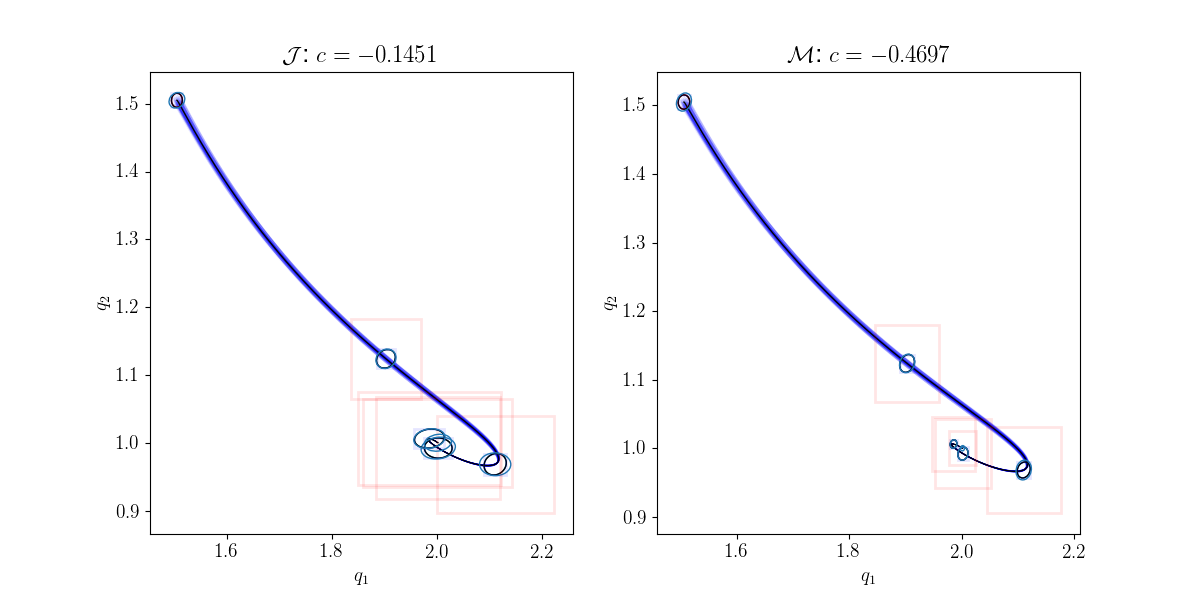

In [33]:
# %matplotlib ipympl

# fig, axs = plt.subplots(1,3,figsize=(10, 3))
fig, axs = plt.subplots(1,2,figsize=(12, 6))

from math import floor
mc_N = 1000
mc_x0s = jnp.vstack((irx.utils.gen_ics(ix0, mc_N), x0))
mc_tf = T*N
mc_dt = dt
mc_T = floor(mc_tf/mc_dt)
mc_trajs = jax.vmap(rollout_undisturbed)(mc_x0s)

for ax in axs[:2] :
    for i in range(mc_N) :
        if e0.V(mc_trajs[i, 0]) <= 1. :
            ax.plot(mc_trajs[i, :mc_T, 0], mc_trajs[i, :mc_T, 1], 'b', alpha=0.1, zorder=-1, lw=0.2)
    ax.plot(mc_trajs[mc_N, :mc_T, 0], mc_trajs[mc_N, :mc_T, 1], 'black', alpha=1, zorder=-1, lw=1)

    e0.plot_projection(ax, 0, 1, color='red')

# axs[2].scatter(mc_trajs[:mc_N, -1, 0], mc_trajs[:mc_N, -1, 1], c='b', s=1, alpha=0.1)
# axs[2].scatter(mc_trajs[mc_N, -1, 0], mc_trajs[mc_N, -1, 1], c='r', s=1, alpha=0.5)

def reach_P_contraction (rollout, e0:Ellipsoid, i0:irx.Interval, ax, T:float, N:int, dt:float, mjacM=True) :
    """
    For now, rollout is a function that takes x0 (interval) and returns xx, xnom, M.
    """

    ee = [e0]
    ii = [i0]

    for i in range(N) :
        ixT = ii[-1]
        ei = ee[i]
        P1 = np.array(ei.P)

        ix0 = iover(ei) & ixT
        xnom0 = ei.xc
        xx, xnom, M = rollout(ix0, xnom0, mjacM)
        ixT = irx.ut2i(xx[-1])
        ii.append(ixT)
        ulx, olx = irx.i2lu(ix0 - xnom[0])
        M_c = gsc(M)
        prevc = jnp.max(jnp.real(jnp.array([jnp.linalg.eigvals(Mi) for Mi in M_c]))) 
        print(prevc)

        print(f'{i=}')
        # Prepare SDP for line search over c
        c = cp.Parameter()

        P2 = cp.Variable((4,4), PSD=True)
        Gam = cp.Variable(4, nonneg=True)
        tau = cp.Variable(1, nonneg=True)
        dGam = cp.diag(Gam)
        
        cons = []
        cons.append(P2 << P1)
        cons.extend([M.T @ P2 + P2 @ M << 2*c*P2 for M in M_c])
        prob = cp.Problem(cp.Maximize(cp.log_det(P2)), cons)

        c.value = np.asarray(prevc)

        ei.plot_projection(ax)
        irx.utils.draw_iarray(ax, ix0, alpha=0.1, ec='blue')
        irx.utils.draw_iarray(ax, ixT, alpha=0.1, ec='red')

        j = 0
        while prob.status != 'optimal' and j < 100:
            # c.value = c.value + 0.0025
            j += 1
            c.value = c.value + 0.005
            print(f'Trying c={c.value:.4f}', end='\r')
            try :
                # prob.solve(solver=cp.MOSEK, mosek_params={'MSK_IPAR_NUM_THREADS': 10})
                prob.solve(solver=cp.MOSEK, mosek_params={'MSK_IPAR_NUM_THREADS': 10}, warm_start=True, verbose=False)
            except KeyboardInterrupt :
                raise KeyboardInterrupt
            except :
                pass

        print(f'{prob.status}: {c.value}')

        # pretitle = 'mjacM' if mjacM else 'jacM'
        pretitle = '$\\mathcal{M}$' if mjacM else '$\\mathcal{J}$'
        color = 'tab:blue' if mjacM else 'tab:orange'

        Ellipsoid(P2.value, xnom0).plot_projection(ax, color='tab:blue')
        Ellipsoid(P2.value*np.exp(-c.value*T), xnom[-1]).plot_projection(ax, color='tab:blue')
        # Ellipsoid(P2.value*np.exp(-c.value*T), xnom[-1]).plot_projection(axs[2], rescale=True, color=color, label=pretitle)

        ax.set_title(pretitle + f': $c = {c.value:.4f}$')

        ee.append(Ellipsoid(P2.value*np.exp(-c.value*T), xnom[-1]))

reach_P_contraction(rollout, e0, ix0, axs[0], T, N, dt, False)
reach_P_contraction(rollout, e0, ix0, axs[1], T, N, dt, True)
axs[0].set_xlabel('$q_1$'); axs[0].set_ylabel('$q_2$')
axs[1].set_xlabel('$q_1$'); axs[1].set_ylabel('$q_2$')
# axs[2].legend()

# fig.tight_layout()
# fig.savefig('RobotArm.pdf')
plt.show()



In [32]:
# axs[0].set_xlim(1.95,2.05); axs[1].set_xlim(1.95,2.05)
# axs[0].set_ylim(0.95,1.05); axs[1].set_ylim(0.95,1.05)

# plt.show()